In [1]:
import numpy as np
import pandas as pd
import os
import glob
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
RANDOM_SEED = 42
tf.random.set_seed(RANDOM_SEED)

# Training configuration
BATCH_SIZE = 8
IMAGE_SIZE = 224
NUM_CLASSES = 14
EPOCHS = 100
LEARNING_RATE = 1e-4
np.random.seed(RANDOM_SEED)

# Focal Loss hyperparameters
ALPHA = 0.25  # Weighting factor for rare class (positive samples)
GAMMA = 2.0   # Focusing parameter

tf.keras.mixed_precision.set_global_policy('mixed_float16')
print("Mixed precision training enabled")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 4050 Laptop GPU, compute capability 8.9
Mixed precision training enabled
TensorFlow version: 2.10.0
GPU Available: True


In [4]:
BASE_DIR = "./dataset_unbalanced/"
CSV_PATH = os.path.join(BASE_DIR, "Data_Entry_2017.csv")
IMAGE_DIR = os.path.join(BASE_DIR, "images")

# Disease labels for multi-label classification
DISEASE_LABELS = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass',
    'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'
]

print(f"Number of disease classes: {len(DISEASE_LABELS)}")
print(f"Disease labels: {DISEASE_LABELS}")

# Load dataset
df = pd.read_csv(CSV_PATH)
df = df.rename(columns={'Image Index': 'Path'})

# Create binary columns for each disease label
for disease in DISEASE_LABELS:
    df[disease] = df['Finding Labels'].apply(lambda x: int(disease in x.split('|')))

df = df[['Path'] + DISEASE_LABELS]

print(f"Total samples: {len(df)}")
print(f"Dataset shape: {df.shape}")

Number of disease classes: 14
Disease labels: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']
Total samples: 112120
Dataset shape: (112120, 15)


In [5]:
# Create stratified split based on disease presence
df['disease_count'] = df[DISEASE_LABELS].sum(axis=1)
df['has_any_disease'] = (df['disease_count'] > 0).astype(int)

# Stratified split to maintain disease distribution
train_df, val_df = train_test_split(
    df, 
    test_size=0.2, 
    random_state=RANDOM_SEED,
    stratify=df['has_any_disease']
)

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Train/Val ratio: {len(train_df)/len(val_df):.2f}")

# Verify stratification worked
train_positive_rate = train_df['has_any_disease'].mean()
val_positive_rate = val_df['has_any_disease'].mean()
print(f"Training positive rate: {train_positive_rate:.3f}")
print(f"Validation positive rate: {val_positive_rate:.3f}")
print(f"Stratification difference: {abs(train_positive_rate - val_positive_rate):.4f}")

# Reset indices
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)


Training samples: 89696
Validation samples: 22424
Train/Val ratio: 4.00
Training positive rate: 0.462
Validation positive rate: 0.462
Stratification difference: 0.0000


Class Distribution in Imbalanced Dataset:
Atelectasis         : 11559 samples (10.31%)
Cardiomegaly        :  2776 samples ( 2.48%)
Consolidation       :  4667 samples ( 4.16%)
Edema               :  2303 samples ( 2.05%)
Effusion            : 13317 samples (11.88%)
Emphysema           :  2516 samples ( 2.24%)
Fibrosis            :  1686 samples ( 1.50%)
Hernia              :   227 samples ( 0.20%)
Infiltration        : 19894 samples (17.74%)
Mass                :  5782 samples ( 5.16%)
Nodule              :  6331 samples ( 5.65%)
Pleural_Thickening  :  3385 samples ( 3.02%)
Pneumonia           :  1431 samples ( 1.28%)
Pneumothorax        :  5302 samples ( 4.73%)


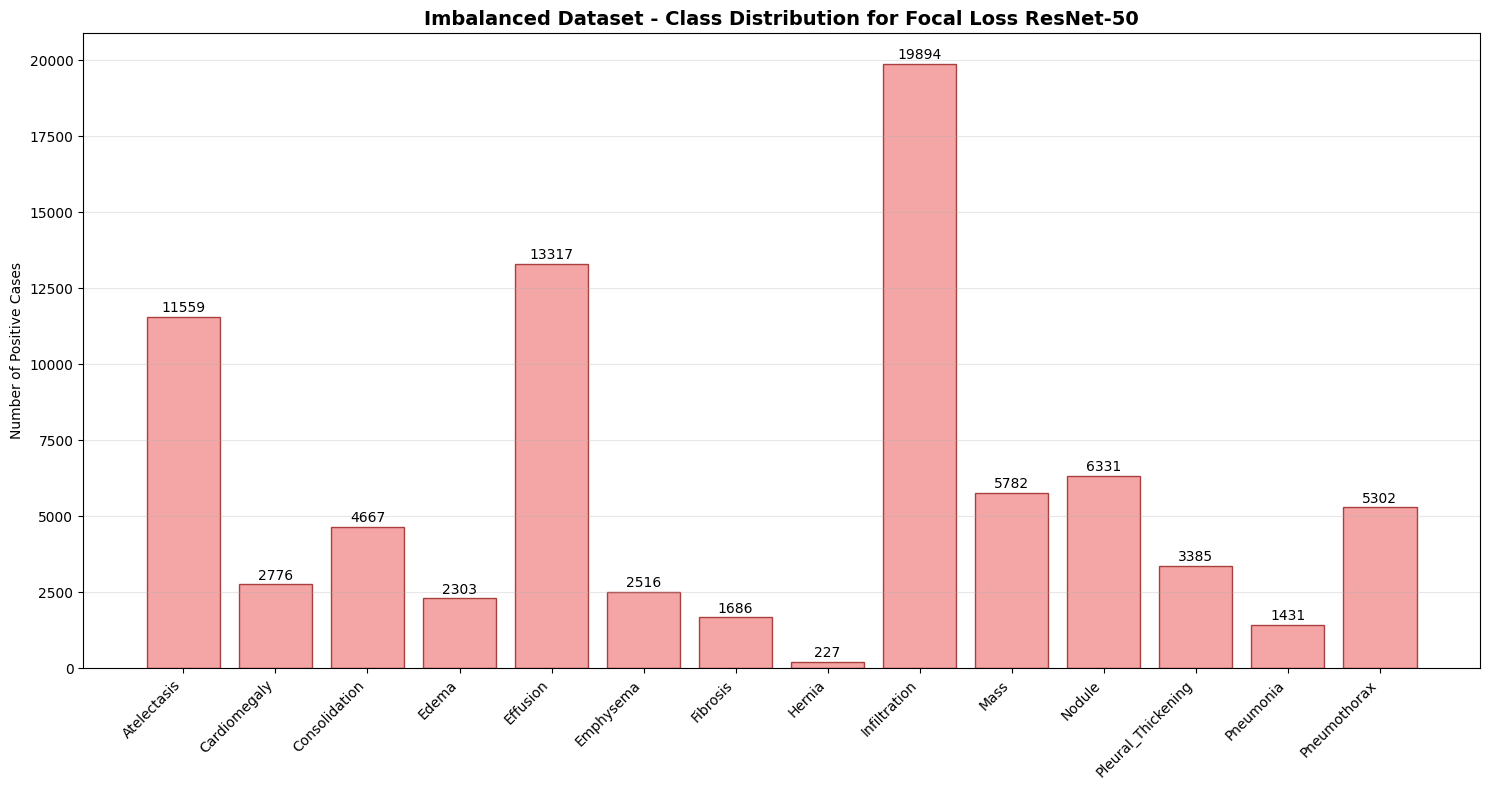


Dataset Balance Analysis:
Minimum class count: 227
Maximum class count: 19894
Balance ratio: 0.011
Coefficient of variation: 0.951


In [6]:
# Analyze class distribution
class_counts = df[DISEASE_LABELS].sum()
class_percentages = (class_counts / len(df)) * 100

print("Class Distribution in Imbalanced Dataset:")
print("=" * 50)
for label, count, percentage in zip(DISEASE_LABELS, class_counts, class_percentages):
    print(f"{label:20s}: {count:5d} samples ({percentage:5.2f}%)")

# Visualize class distribution
plt.figure(figsize=(15, 8))
bars = plt.bar(range(len(DISEASE_LABELS)), class_counts, 
               color='lightcoral', alpha=0.7, edgecolor='darkred', linewidth=1)
plt.xticks(range(len(DISEASE_LABELS)), DISEASE_LABELS, rotation=45, ha='right')
plt.ylabel('Number of Positive Cases')
plt.title('Imbalanced Dataset - Class Distribution for Focal Loss ResNet-50', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, count in zip(bars, class_counts):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 50,
             f'{count}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Calculate dataset balance metrics
min_class_count = class_counts.min()
max_class_count = class_counts.max()
balance_ratio = min_class_count / max_class_count

print(f"\nDataset Balance Analysis:")
print(f"Minimum class count: {min_class_count}")
print(f"Maximum class count: {max_class_count}")
print(f"Balance ratio: {balance_ratio:.3f}")
print(f"Coefficient of variation: {(class_counts.std() / class_counts.mean()):.3f}")

In [8]:
# Reset indices
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

def load_and_preprocess_image(image_path, labels, is_training=True):
    """Load and preprocess image with optional augmentation"""
    # Load image
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.cast(image, tf.float32)
    
    # Resize to target size
    image = tf.image.resize(image, [IMAGE_SIZE, IMAGE_SIZE])
    
    # Normalize to [0, 1]
    image = image / 255.0
    
    if is_training:
        # Data augmentation for training (medical image appropriate)
        # Small rotations
        image = tf.image.rot90(image, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
        
        # Random brightness adjustment
        image = tf.image.random_brightness(image, max_delta=0.1)
        
        # Random contrast adjustment
        image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
        
        # Small random crops with padding
        image = tf.image.resize_with_crop_or_pad(image, IMAGE_SIZE + 20, IMAGE_SIZE + 20)
        image = tf.image.random_crop(image, [IMAGE_SIZE, IMAGE_SIZE, 3])
    
    # Ensure final normalization
    image = tf.clip_by_value(image, 0.0, 1.0)
    
    return image, labels

def create_tf_dataset(dataframe, image_dir, batch_size, is_training=True):
    """Create optimized tf.data.Dataset with prefetching"""
    
    # Prepare file paths and labels
    image_paths = [os.path.join(image_dir, path) for path in dataframe['Path'].values]
    labels = dataframe[DISEASE_LABELS].values.astype(np.float32)
    
    # Create dataset from paths and labels
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    
    if is_training:
        # Shuffle for training
        dataset = dataset.shuffle(buffer_size=1000, seed=RANDOM_SEED)
    
    # Map preprocessing function
    dataset = dataset.map(
        lambda path, label: load_and_preprocess_image(path, label, is_training),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    
    # Batch the data
    dataset = dataset.batch(batch_size, drop_remainder=is_training)
    
    # Prefetch for performance
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    if is_training:
        # Repeat for multiple epochs
        dataset = dataset.repeat()
    
    return dataset

# Create optimized datasets
print("Creating optimized tf.data pipelines...")

train_dataset = create_tf_dataset(
    train_df, 
    IMAGE_DIR, 
    BATCH_SIZE, 
    is_training=True
)

val_dataset = create_tf_dataset(
    val_df, 
    IMAGE_DIR, 
    BATCH_SIZE, 
    is_training=False
)

# Calculate steps per epoch
steps_per_epoch = len(train_df) // BATCH_SIZE
validation_steps = len(val_df) // BATCH_SIZE

print(f"Steps per epoch: {steps_per_epoch}")
print(f"Validation steps: {validation_steps}")
print("Optimized data pipeline created with tf.data.AUTOTUNE prefetching")

Creating optimized tf.data pipelines...
Steps per epoch: 11212
Validation steps: 2803
Optimized data pipeline created with tf.data.AUTOTUNE prefetching


In [20]:
# Custom Focal Loss Implementation
class FocalLoss(tf.keras.losses.Loss):
    """
    Focal Loss for addressing class imbalance in multi-label classification.
    
    Focal Loss = -alpha * (1-p)^gamma * log(p) for positive samples
    Focal Loss = -(1-alpha) * p^gamma * log(1-p) for negative samples
    
    Args:
        alpha: Weighting factor for rare class (typically 0.25)
        gamma: Focusing parameter (typically 2.0)
        from_logits: Whether predictions are logits or probabilities
    """
    
    def __init__(self, alpha=0.25, gamma=2.0, from_logits=False, reduction=tf.keras.losses.Reduction.AUTO, name="focal_loss", **kwargs):
        super(FocalLoss, self).__init__(reduction=reduction, name=name, **kwargs)
        self.alpha = alpha
        self.gamma = gamma
        self.from_logits = from_logits
        
    def call(self, y_true, y_pred):
        # Ensure float32 for mixed precision compatibility
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        
        # If predictions are logits, apply sigmoid
        if self.from_logits:
            y_pred = tf.nn.sigmoid(y_pred)
        
        # Clip predictions to prevent log(0)
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
        
        # Calculate focal loss components
        # For positive samples: -alpha * (1-p)^gamma * log(p)
        positive_loss = -self.alpha * tf.pow(1.0 - y_pred, self.gamma) * tf.math.log(y_pred)
        
        # For negative samples: -(1-alpha) * p^gamma * log(1-p)
        negative_loss = -(1.0 - self.alpha) * tf.pow(y_pred, self.gamma) * tf.math.log(1.0 - y_pred)
        
        # Combine based on true labels
        focal_loss = y_true * positive_loss + (1.0 - y_true) * negative_loss
        
        # Return mean loss across all samples and classes
        return tf.reduce_mean(focal_loss)
    
    def get_config(self):
        config = super(FocalLoss, self).get_config()
        config.update({
            'alpha': self.alpha,
            'gamma': self.gamma,
            'from_logits': self.from_logits
        })
        return config

def create_focal_loss_resnet50(input_shape=(224, 224, 3), num_classes=14):
    """
    Create ResNet-50 model with Focal Loss for imbalanced classification
    
    Architecture:
    - Standard ResNet-50 backbone (ImageNet pretrained)
    - Global Average Pooling
    - Dense classification head optimized for focal loss
    """
    
    # Input layer
    inputs = tf.keras.Input(shape=input_shape, name='input_images')
    
    # ResNet-50 backbone (pretrained on ImageNet)
    backbone = tf.keras.applications.ResNet50(
        weights='imagenet',
        include_top=False,
        input_tensor=inputs,
        pooling=None
    )
    
    # Freeze early layers, train only top layers for transfer learning
    trainable_layers = 30
    for i, layer in enumerate(backbone.layers):
        if i < len(backbone.layers) - trainable_layers:
            layer.trainable = False
        else:
            layer.trainable = True
    
    # Get features from ResNet backbone
    x = backbone.output  # Shape: (batch_size, 7, 7, 2048)
    
    # Global Average Pooling to reduce spatial dimensions
    x = tf.keras.layers.GlobalAveragePooling2D(name='global_avg_pool')(x)
    
    # Classification head with regularization (optimized for focal loss)
    x = tf.keras.layers.Dense(512, activation='relu', name='dense_512')(x)
    x = tf.keras.layers.BatchNormalization(name='bn_512')(x)
    x = tf.keras.layers.Dropout(0.4, name='dropout_512')(x)  # Slightly higher dropout
    
    x = tf.keras.layers.Dense(256, activation='relu', name='dense_256')(x)
    x = tf.keras.layers.BatchNormalization(name='bn_256')(x)
    x = tf.keras.layers.Dropout(0.3, name='dropout_256')(x)
    
    # Final output layer (float32 for mixed precision compatibility)
    # Note: We use sigmoid activation as focal loss expects probabilities
    outputs = tf.keras.layers.Dense(
        num_classes, 
        activation='sigmoid',
        dtype='float32',
        name='predictions'
    )(x)
    
    # Create model
    model = tf.keras.Model(inputs=inputs, outputs=outputs, name='FocalLoss_ResNet50')
    
    return model, backbone

# Create model with focal loss
print("Creating Focal Loss ResNet-50 model...")
model, backbone = create_focal_loss_resnet50(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    num_classes=NUM_CLASSES
)

print(f"Model created successfully!")
print(f"Total parameters: {model.count_params():,}")

# Count trainable parameters
trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {model.count_params() - trainable_params:,}")

# Display model architecture
model.summary(line_length=100)

# Create focal loss instance
focal_loss = FocalLoss(alpha=ALPHA, gamma=GAMMA, from_logits=False)

# Custom AUC metric that handles the focal loss output properly
class MultiLabelAUC(tf.keras.metrics.Metric):
    """Multi-label AUC metric for focal loss models"""
    
    def __init__(self, num_classes=NUM_CLASSES, name='multi_auc', **kwargs):
        super(MultiLabelAUC, self).__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.auc_metrics = [tf.keras.metrics.AUC(name=f'auc_{i}') for i in range(num_classes)]
    
    def update_state(self, y_true, y_pred, sample_weight=None):
        for i in range(self.num_classes):
            self.auc_metrics[i].update_state(
                y_true[:, i], y_pred[:, i], sample_weight=sample_weight
            )
    
    def result(self):
        aucs = [metric.result() for metric in self.auc_metrics]
        return tf.reduce_mean(aucs)
    
    def reset_state(self):
        for metric in self.auc_metrics:
            metric.reset_state()

# Compile model with focal loss
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE,
        beta_1=0.9,
        beta_2=0.999,
        epsilon=1e-7
    ),
    loss=focal_loss,  # Use custom focal loss
    metrics=[
        'binary_accuracy',
        MultiLabelAUC(num_classes=NUM_CLASSES, name='multi_auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

print(f"Model compiled with Focal Loss (alpha={ALPHA}, gamma={GAMMA})")

# Create output directory
os.makedirs('./output', exist_ok=True)

# Define callbacks for training
callbacks = [
    # Save best model based on validation multi_auc
    tf.keras.callbacks.ModelCheckpoint(
        filepath='./output/focal_loss_resnet50_best.keras',
        monitor='val_multi_auc',
        mode='max',
        save_best_only=True,
        save_weights_only=False,
        verbose=1,
        save_freq='epoch'
    ),
    
    # Early stopping to prevent overfitting
    tf.keras.callbacks.EarlyStopping(
        monitor='val_multi_auc',
        mode='max',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    
    # Reduce learning rate on plateau
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_multi_auc',
        mode='max',
        factor=0.3,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    
    # CSV logger for training history
    tf.keras.callbacks.CSVLogger(
        './output/focal_loss_resnet50_training.csv',
        separator=',',
        append=False
    )
]

print("Training callbacks configured for focal loss optimization")

Creating Focal Loss ResNet-50 model...
Model created successfully!
Total parameters: 24,774,798
Trainable parameters: 15,635,726
Frozen parameters: 9,139,072
Model: "FocalLoss_ResNet50"
____________________________________________________________________________________________________
 Layer (type)                    Output Shape          Param #     Connected to                     
 input_images (InputLayer)       [(None, 224, 224, 3)  0           []                               
                                 ]                                                                  
                                                                                                    
 conv1_pad (ZeroPadding2D)       (None, 230, 230, 3)   0           ['input_images[0][0]']           
                                                                                                    
 conv1_conv (Conv2D)             (None, 112, 112, 64)  9472        ['conv1_pad[0][0]']              
      

In [11]:
print("Starting Focal Loss ResNet-50 Training...")
print("=" * 70)
print(f"Training configuration:")
print(f"  - Model: ResNet-50 with Focal Loss")
print(f"  - Loss function: Focal Loss (α={ALPHA}, γ={GAMMA})")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Learning rate: {LEARNING_RATE}")
print(f"  - Max epochs: {EPOCHS}")
print(f"  - Mixed precision: Enabled")
print(f"  - Dataset imbalance: Balance ratio = {balance_ratio:.3f}")
print("=" * 70)

# Train the model
history = model.fit(
    train_dataset,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    validation_data=val_dataset,
    validation_steps=validation_steps,
    callbacks=callbacks,
    verbose=1
)

print("Training completed!")

# Save final model
model.save('./output/focal_loss_resnet50_final.keras')
print("Final model saved")

Starting Focal Loss ResNet-50 Training...
Training configuration:
  - Model: ResNet-50 with Focal Loss
  - Loss function: Focal Loss (α=0.25, γ=2.0)
  - Batch size: 8
  - Learning rate: 0.0001
  - Max epochs: 100
  - Mixed precision: Enabled
  - Dataset imbalance: Balance ratio = 0.011
Epoch 1/100
11212/11212 [==============================] - ETA: 0s - loss: 0.0479 - binary_accuracy: 0.8994 - multi_auc: 0.5067 - precision: 0.0593 - recall: 0.0636
Epoch 1: val_multi_auc improved from -inf to 0.55972, saving model to ./output\focal_loss_resnet50_best.keras
11212/11212 [==============================] - 735s 64ms/step - loss: 0.0479 - binary_accuracy: 0.8994 - multi_auc: 0.5067 - precision: 0.0593 - recall: 0.0636 - val_loss: 0.0193 - val_binary_accuracy: 0.9482 - val_multi_auc: 0.5597 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lr: 1.0000e-04
Epoch 2/100
11212/11212 [==============================] - ETA: 0s - loss: 0.0206 - binary_accuracy: 0.9472 - multi_auc: 0.5176 - preci

In [23]:
# Continue training from epoch 35
print("Continuing training...")

# Load model with custom objects
model = tf.keras.models.load_model('./output/focal_loss_resnet50_best.keras', 
                                   custom_objects={'FocalLoss': FocalLoss,
                                                 'MultiLabelAUC': MultiLabelAUC})

# Continue training with existing callbacks
history_continued = model.fit(
    train_dataset,
    steps_per_epoch=steps_per_epoch,
    epochs=100,
    initial_epoch=35,  # Continue from epoch 35
    validation_data=val_dataset,
    validation_steps=validation_steps,
    callbacks=callbacks,  # Use your existing callbacks
    verbose=1
)

print("Training completed! Final model saved by ModelCheckpoint callback.")

Continuing training...
Epoch 36/100
11212/11212 [==============================] - ETA: 0s - loss: 0.0168 - binary_accuracy: 0.9483 - multi_auc: 0.6681 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 36: val_multi_auc improved from -inf to 0.69960, saving model to ./output\focal_loss_resnet50_best.keras
11212/11212 [==============================] - 617s 55ms/step - loss: 0.0168 - binary_accuracy: 0.9483 - multi_auc: 0.6681 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_loss: 0.0169 - val_binary_accuracy: 0.9479 - val_multi_auc: 0.6996 - val_precision: 0.0643 - val_recall: 5.5391e-04 - lr: 9.0000e-06
Epoch 37/100
11212/11212 [==============================] - ETA: 0s - loss: 0.0168 - binary_accuracy: 0.9483 - multi_auc: 0.6681 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 37: val_multi_auc did not improve from 0.69960
11212/11212 [==============================] - 664s 59ms/step - loss: 0.0168 - binary_accuracy: 0.9483 - multi_auc: 0.6681 - precision: 0.0000e+00 - recall: 0

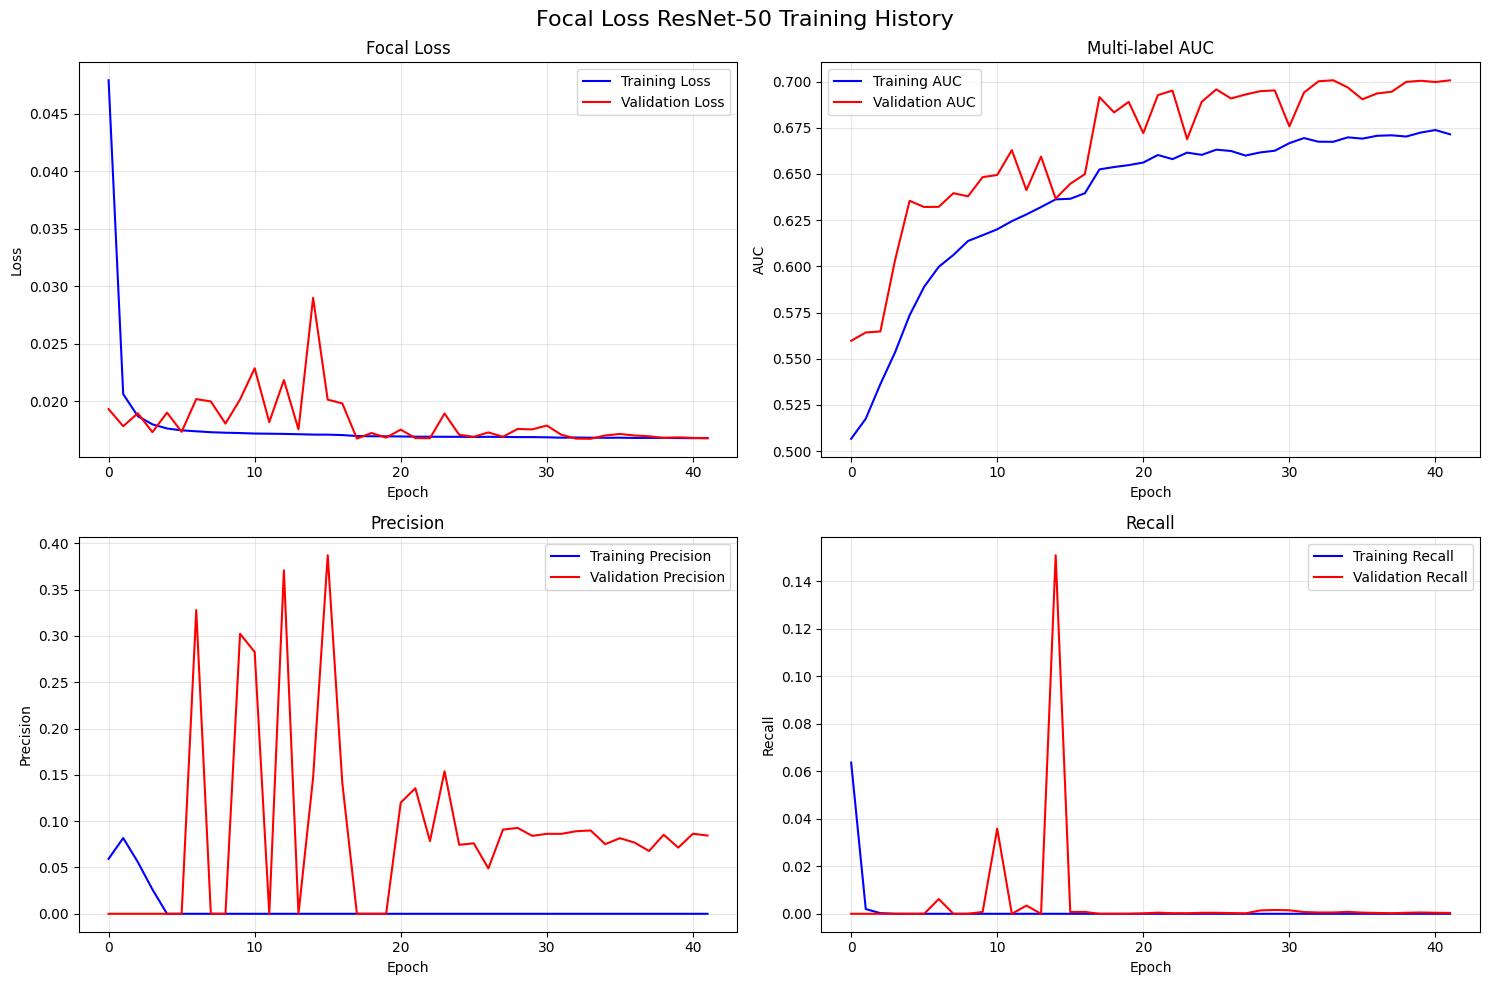


Final Model Evaluation:
Validation Results:
  loss: 0.0169
  binary_accuracy: 0.9478
  multi_auc: 0.7049
  precision: 0.0696
  recall: 0.0007

Focal Loss hyperparameters used:
  Alpha (α): 0.25
  Gamma (γ): 2.0
  Benefits: Addresses class imbalance by focusing on hard examples

Model files saved:
  - Best model: ./output/focal_loss_resnet50_best.keras
  - Final model: ./output/focal_loss_resnet50_final.keras
  - Training log: ./output/focal_loss_resnet50_training.csv
  - Training plots: ./output/focal_loss_training_history.png


In [24]:
# Plot training history
def plot_training_history(history):
    """Plot training and validation metrics"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Focal Loss ResNet-50 Training History', fontsize=16)
    
    # Loss
    axes[0, 0].plot(history.history['loss'], label='Training Loss', color='blue')
    axes[0, 0].plot(history.history['val_loss'], label='Validation Loss', color='red')
    axes[0, 0].set_title('Focal Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # AUC
    axes[0, 1].plot(history.history['multi_auc'], label='Training AUC', color='blue')
    axes[0, 1].plot(history.history['val_multi_auc'], label='Validation AUC', color='red')
    axes[0, 1].set_title('Multi-label AUC')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('AUC')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Precision
    axes[1, 0].plot(history.history['precision'], label='Training Precision', color='blue')
    axes[1, 0].plot(history.history['val_precision'], label='Validation Precision', color='red')
    axes[1, 0].set_title('Precision')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Recall
    axes[1, 1].plot(history.history['recall'], label='Training Recall', color='blue')
    axes[1, 1].plot(history.history['val_recall'], label='Validation Recall', color='red')
    axes[1, 1].set_title('Recall')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('./output/focal_loss_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

# Plot training history
plot_training_history(history)

# Evaluate model performance
print("\nFinal Model Evaluation:")
print("=" * 50)

# Load best model for evaluation
best_model = tf.keras.models.load_model('./output/focal_loss_resnet50_best.keras', 
                                       custom_objects={'FocalLoss': FocalLoss,
                                                     'MultiLabelAUC': MultiLabelAUC})

# Evaluate on validation set
val_results = best_model.evaluate(val_dataset, steps=validation_steps, verbose=0)

print(f"Validation Results:")
for name, value in zip(best_model.metrics_names, val_results):
    print(f"  {name}: {value:.4f}")

print(f"\nFocal Loss hyperparameters used:")
print(f"  Alpha (α): {ALPHA}")
print(f"  Gamma (γ): {GAMMA}")
print(f"  Benefits: Addresses class imbalance by focusing on hard examples")

print("\nModel files saved:")
print("  - Best model: ./output/focal_loss_resnet50_best.keras")
print("  - Final model: ./output/focal_loss_resnet50_final.keras")
print("  - Training log: ./output/focal_loss_resnet50_training.csv")
print("  - Training plots: ./output/focal_loss_training_history.png")

Starting threshold optimization...
Getting model predictions on validation set...
2803/2803 [==============================] - 97s 34ms/step
Predictions shape: (22424, 14)
True labels shape: (22424, 14)

Optimizing thresholds for each disease class...
Optimizing Atelectasis...
  Best threshold: 0.250 (score: 0.270)
Optimizing Cardiomegaly...
  Best threshold: 0.200 (score: 0.140)
Optimizing Consolidation...
  Best threshold: 0.200 (score: 0.164)
Optimizing Edema...
  Best threshold: 0.200 (score: 0.162)
Optimizing Effusion...
  Best threshold: 0.250 (score: 0.339)
Optimizing Emphysema...
  Best threshold: 0.150 (score: 0.087)
Optimizing Fibrosis...
  Best threshold: 0.150 (score: 0.075)
Optimizing Hernia...
  Best threshold: 0.100 (score: 0.040)
Optimizing Infiltration...
  Best threshold: 0.300 (score: 0.342)
Optimizing Mass...
  Best threshold: 0.200 (score: 0.158)
Optimizing Nodule...
  Best threshold: 0.200 (score: 0.131)
Optimizing Pleural_Thickening...
  Best threshold: 0.200 (sc

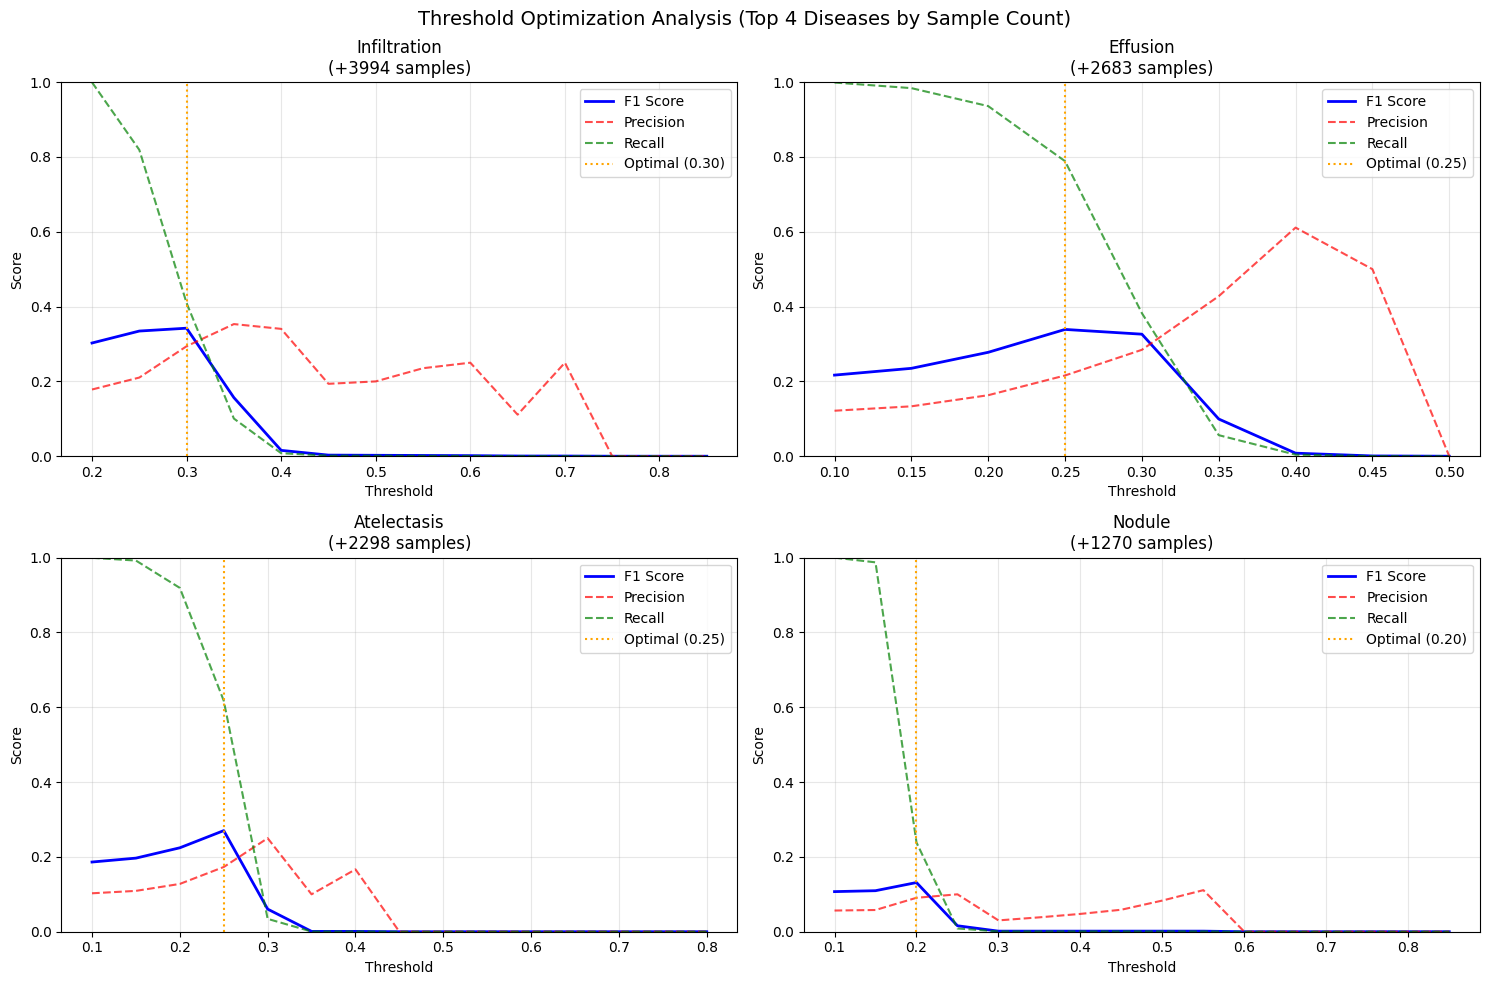

Threshold optimization complete!
Optimal thresholds saved to './output/optimal_thresholds.json'


In [25]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, roc_curve
import matplotlib.pyplot as plt

def optimize_thresholds_per_class(model, val_dataset, val_df, disease_labels, method='f1'):
    """
    Find optimal threshold for each disease class
    
    Args:
        model: trained model
        val_dataset: validation tf.data.Dataset 
        val_df: validation dataframe with true labels
        disease_labels: list of disease names
        method: 'f1', 'youden', or 'precision_recall_balance'
    
    Returns:
        optimal_thresholds: dict with optimal threshold for each disease
        results: detailed results for analysis
    """
    
    print("Getting model predictions on validation set...")
    
    # Get predictions from model
    val_predictions = model.predict(val_dataset, verbose=1)
    
    # Get true labels
    y_true = val_df[disease_labels].values
    
    print(f"Predictions shape: {val_predictions.shape}")
    print(f"True labels shape: {y_true.shape}")
    
    optimal_thresholds = {}
    results = {}
    
    print("\nOptimizing thresholds for each disease class...")
    print("=" * 60)
    
    for i, disease in enumerate(disease_labels):
        print(f"Optimizing {disease}...")
        
        # Get predictions and true labels for this disease
        y_pred_proba = val_predictions[:, i]
        y_true_class = y_true[:, i]
        
        # Test different thresholds
        thresholds_to_test = np.arange(0.1, 0.9, 0.05)
        best_threshold = 0.5
        best_score = 0.0
        
        threshold_results = []
        
        for threshold in thresholds_to_test:
            y_pred_binary = (y_pred_proba >= threshold).astype(int)
            
            # Skip if all predictions are 0 or 1
            if len(np.unique(y_pred_binary)) == 1:
                continue
                
            # Calculate metrics
            f1 = f1_score(y_true_class, y_pred_binary)
            precision = precision_score(y_true_class, y_pred_binary, zero_division=0)
            recall = recall_score(y_true_class, y_pred_binary, zero_division=0)
            
            threshold_results.append({
                'threshold': threshold,
                'f1': f1,
                'precision': precision,
                'recall': recall
            })
            
            # Choose best threshold based on method
            if method == 'f1':
                score = f1
            elif method == 'youden':
                # Youden's J statistic (sensitivity + specificity - 1)
                tn = np.sum((y_true_class == 0) & (y_pred_binary == 0))
                fp = np.sum((y_true_class == 0) & (y_pred_binary == 1))
                specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
                score = recall + specificity - 1
            elif method == 'precision_recall_balance':
                # Balanced F1 where precision and recall are equally important
                score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
            
            if score > best_score:
                best_score = score
                best_threshold = threshold
        
        optimal_thresholds[disease] = best_threshold
        results[disease] = {
            'best_threshold': best_threshold,
            'best_score': best_score,
            'threshold_results': threshold_results,
            'class_distribution': {
                'positive_samples': int(y_true_class.sum()),
                'negative_samples': int(len(y_true_class) - y_true_class.sum()),
                'positive_rate': float(y_true_class.mean())
            }
        }
        
        # Print results for this disease
        print(f"  Best threshold: {best_threshold:.3f} (score: {best_score:.3f})")
        
    return optimal_thresholds, results

def evaluate_with_optimized_thresholds(model, val_dataset, val_df, disease_labels, optimal_thresholds):
    """
    Evaluate model performance using optimized thresholds
    """
    print("Evaluating with optimized thresholds...")
    
    # Get predictions
    val_predictions = model.predict(val_dataset, verbose=1)
    y_true = val_df[disease_labels].values
    
    # Apply optimized thresholds
    y_pred_optimized = np.zeros_like(val_predictions)
    for i, disease in enumerate(disease_labels):
        threshold = optimal_thresholds[disease]
        y_pred_optimized[:, i] = (val_predictions[:, i] >= threshold).astype(int)
    
    # Calculate metrics for each class
    print("\nPer-class performance with optimized thresholds:")
    print("=" * 80)
    print(f"{'Disease':<20} {'Threshold':<10} {'Precision':<10} {'Recall':<10} {'F1':<10}")
    print("=" * 80)
    
    overall_metrics = {'precision': [], 'recall': [], 'f1': []}
    
    for i, disease in enumerate(disease_labels):
        precision = precision_score(y_true[:, i], y_pred_optimized[:, i], zero_division=0)
        recall = recall_score(y_true[:, i], y_pred_optimized[:, i], zero_division=0)
        f1 = f1_score(y_true[:, i], y_pred_optimized[:, i], zero_division=0)
        
        overall_metrics['precision'].append(precision)
        overall_metrics['recall'].append(recall)
        overall_metrics['f1'].append(f1)
        
        print(f"{disease:<20} {optimal_thresholds[disease]:<10.3f} {precision:<10.3f} {recall:<10.3f} {f1:<10.3f}")
    
    # Calculate macro averages
    macro_precision = np.mean(overall_metrics['precision'])
    macro_recall = np.mean(overall_metrics['recall'])
    macro_f1 = np.mean(overall_metrics['f1'])
    
    print("=" * 80)
    print(f"{'MACRO AVERAGE':<20} {'-':<10} {macro_precision:<10.3f} {macro_recall:<10.3f} {macro_f1:<10.3f}")
    
    return overall_metrics

def plot_threshold_analysis(results, disease_labels):
    """
    Plot threshold analysis for top diseases
    """
    # Select diseases with most samples for plotting
    diseases_by_samples = sorted(
        [(disease, results[disease]['class_distribution']['positive_samples']) 
         for disease in disease_labels],
        key=lambda x: x[1], reverse=True
    )
    
    top_diseases = [d[0] for d in diseases_by_samples[:4]]
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Threshold Optimization Analysis (Top 4 Diseases by Sample Count)', fontsize=14)
    axes = axes.ravel()
    
    for idx, disease in enumerate(top_diseases):
        threshold_data = results[disease]['threshold_results']
        
        thresholds = [r['threshold'] for r in threshold_data]
        f1_scores = [r['f1'] for r in threshold_data]
        precision_scores = [r['precision'] for r in threshold_data]
        recall_scores = [r['recall'] for r in threshold_data]
        
        axes[idx].plot(thresholds, f1_scores, 'b-', label='F1 Score', linewidth=2)
        axes[idx].plot(thresholds, precision_scores, 'r--', label='Precision', alpha=0.7)
        axes[idx].plot(thresholds, recall_scores, 'g--', label='Recall', alpha=0.7)
        
        # Mark optimal threshold
        best_threshold = results[disease]['best_threshold']
        best_f1 = max(f1_scores) if f1_scores else 0
        axes[idx].axvline(x=best_threshold, color='orange', linestyle=':', 
                         label=f'Optimal ({best_threshold:.2f})')
        
        axes[idx].set_title(f'{disease}\n(+{results[disease]["class_distribution"]["positive_samples"]} samples)')
        axes[idx].set_xlabel('Threshold')
        axes[idx].set_ylabel('Score')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)
        axes[idx].set_ylim(0, 1)
    
    plt.tight_layout()
    plt.savefig('./output/threshold_optimization_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

# Usage example:
print("Starting threshold optimization...")

# Optimize thresholds
optimal_thresholds, detailed_results = optimize_thresholds_per_class(
    model=model,
    val_dataset=val_dataset,
    val_df=val_df,
    disease_labels=DISEASE_LABELS,
    method='f1'  # or 'youden' or 'precision_recall_balance'
)

# Evaluate with optimized thresholds
performance_metrics = evaluate_with_optimized_thresholds(
    model=model,
    val_dataset=val_dataset, 
    val_df=val_df,
    disease_labels=DISEASE_LABELS,
    optimal_thresholds=optimal_thresholds
)

# Plot analysis
plot_threshold_analysis(detailed_results, DISEASE_LABELS)

# Save optimal thresholds for future use
import json
with open('./output/optimal_thresholds.json', 'w') as f:
    json.dump(optimal_thresholds, f, indent=2)

print("Threshold optimization complete!")
print(f"Optimal thresholds saved to './output/optimal_thresholds.json'")

Generating predictions...
2803/2803 [==============================] - 91s 32ms/step
Predictions shape: (22424, 14)
True labels shape: (22424, 14)


<Figure size 1500x1200 with 0 Axes>

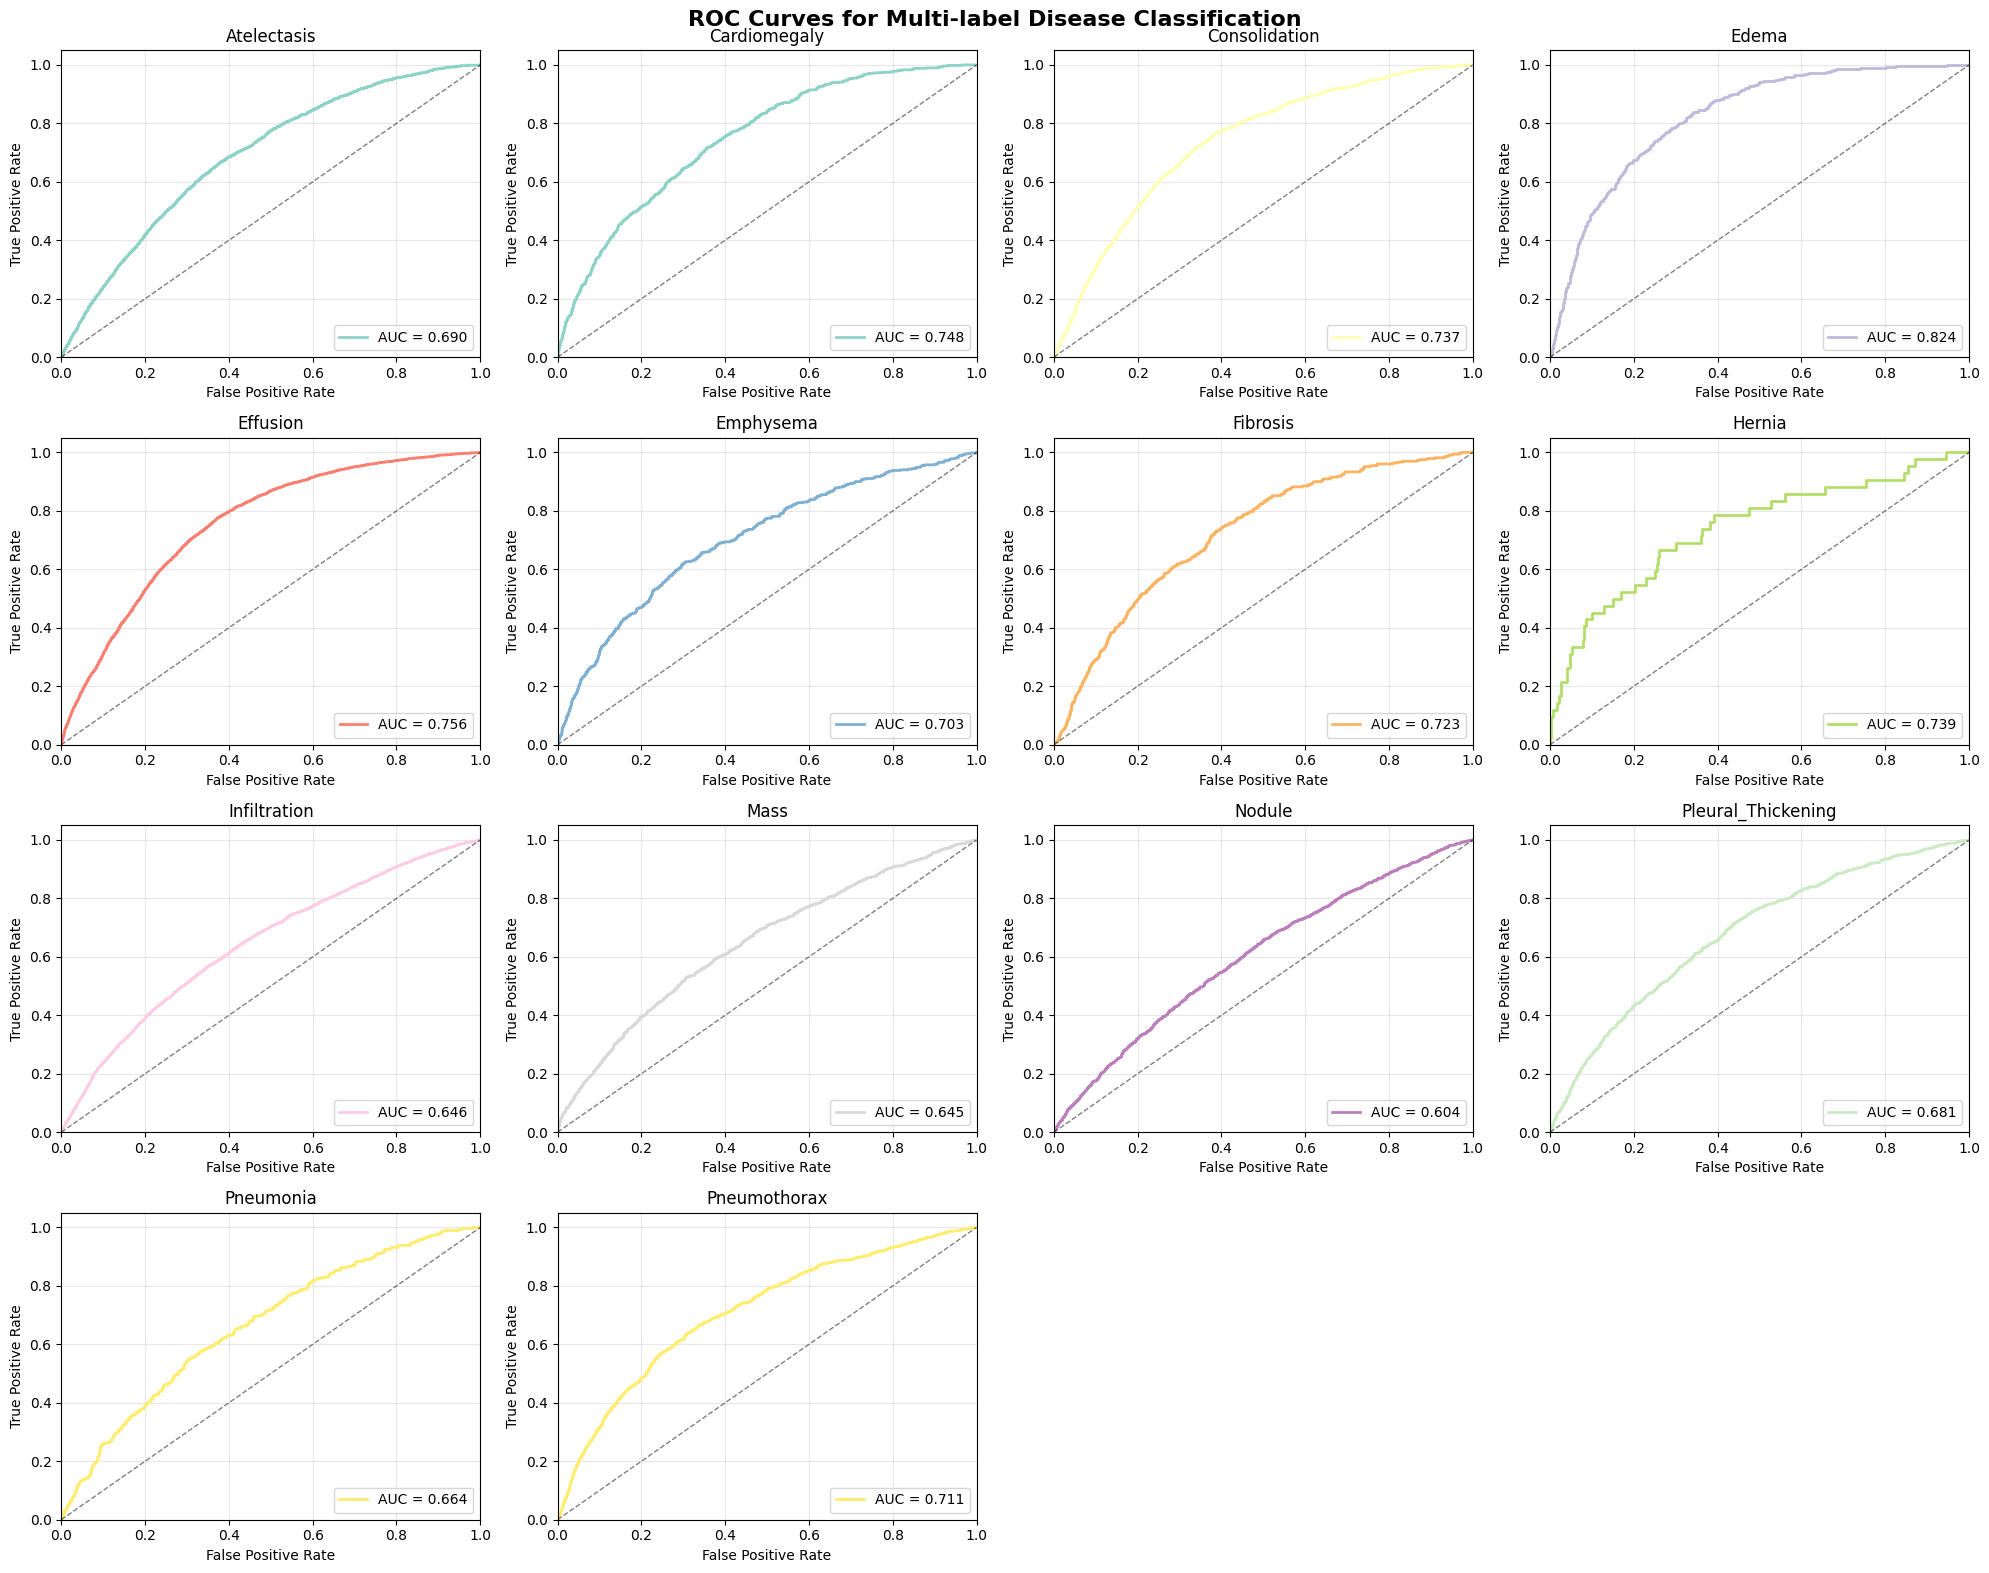

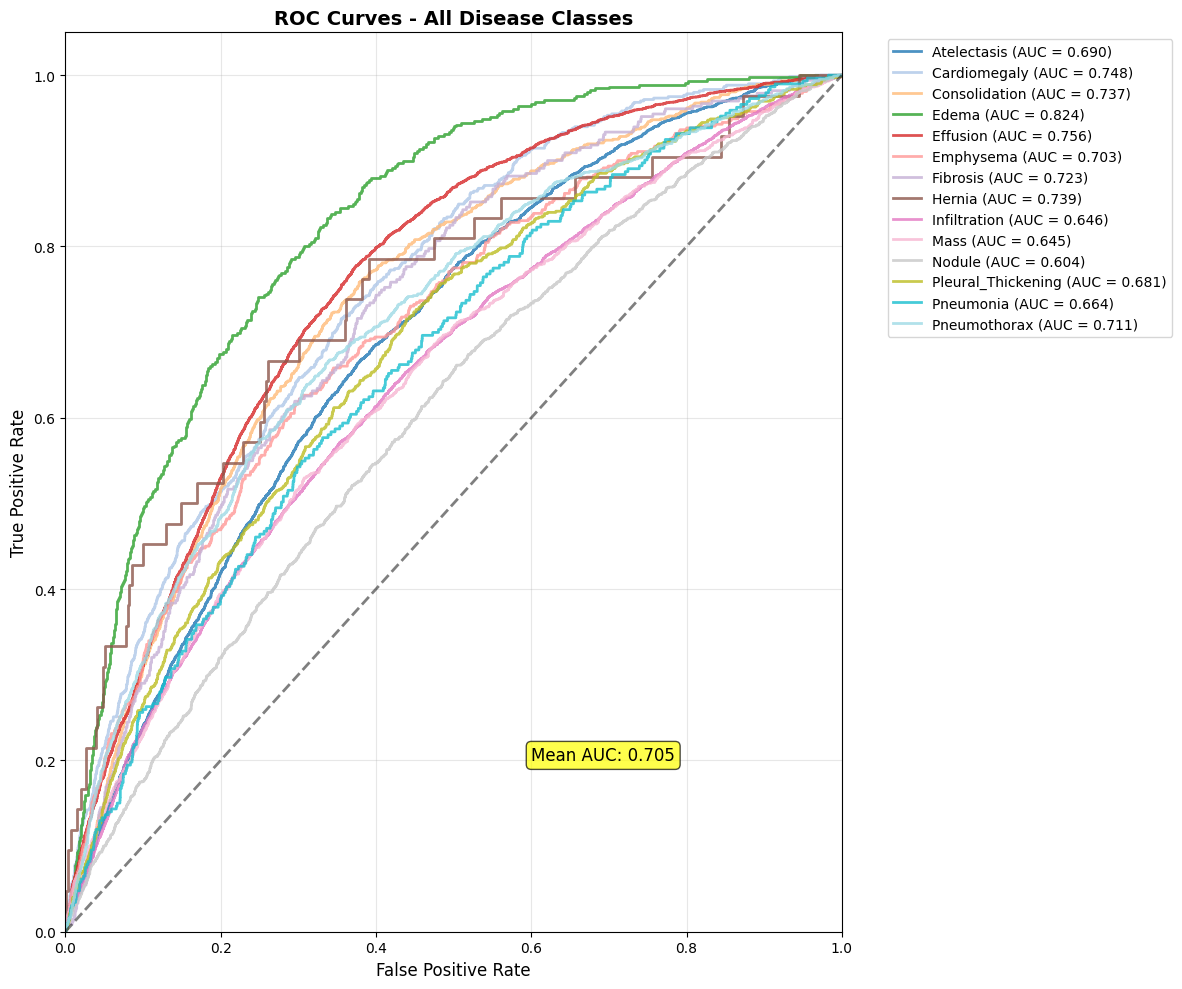


ROC-AUC Scores by Disease:
Atelectasis         : 0.690
Cardiomegaly        : 0.748
Consolidation       : 0.737
Edema               : 0.824
Effusion            : 0.756
Emphysema           : 0.703
Fibrosis            : 0.723
Hernia              : 0.739
Infiltration        : 0.646
Mass                : 0.645
Nodule              : 0.604
Pleural_Thickening  : 0.681
Pneumonia           : 0.664
Pneumothorax        : 0.711
Mean AUC            : 0.705


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import seaborn as sns

# Get predictions and true labels from the model
def get_model_predictions(model, dataset, steps):
    """Get predictions and true labels from the model"""
    print("Generating predictions...")
    
    # Get predictions
    y_pred = model.predict(dataset, steps=steps, verbose=1)
    
    # Get true labels by iterating through dataset
    y_true = []
    count = 0
    for batch_x, batch_y in dataset:
        y_true.append(batch_y.numpy())
        count += 1
        if count >= steps:
            break
    
    y_true = np.vstack(y_true)
    
    print(f"Predictions shape: {y_pred.shape}")
    print(f"True labels shape: {y_true.shape}")
    
    return y_true, y_pred

# Plot ROC curves for each disease class
def plot_roc_curves(y_true, y_pred, disease_labels):
    """Plot ROC curves for each disease class"""
    
    n_classes = len(disease_labels)
    
    # Calculate ROC curve for each class
    fpr = {}
    tpr = {}
    roc_auc = {}
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_pred[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Plot all ROC curves
    plt.figure(figsize=(15, 12))
    
    # Create subplot grid
    fig, axes = plt.subplots(4, 4, figsize=(20, 16))
    fig.suptitle('ROC Curves for Multi-label Disease Classification', fontsize=16, fontweight='bold')
    
    # Colors for different classes
    colors = plt.cm.Set3(np.linspace(0, 1, n_classes))
    
    # Plot individual ROC curves
    for i in range(n_classes):
        row = i // 4
        col = i % 4
        
        axes[row, col].plot(fpr[i], tpr[i], color=colors[i], lw=2,
                           label=f'AUC = {roc_auc[i]:.3f}')
        axes[row, col].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
        axes[row, col].set_xlim([0.0, 1.0])
        axes[row, col].set_ylim([0.0, 1.05])
        axes[row, col].set_xlabel('False Positive Rate')
        axes[row, col].set_ylabel('True Positive Rate')
        axes[row, col].set_title(f'{disease_labels[i]}')
        axes[row, col].legend(loc="lower right")
        axes[row, col].grid(True, alpha=0.3)
    
    # Remove empty subplots
    for i in range(n_classes, 16):
        row = i // 4
        col = i % 4
        fig.delaxes(axes[row, col])
    
    plt.tight_layout()
    plt.show()
    
    return roc_auc

# Plot all ROC curves on single plot
def plot_combined_roc(y_true, y_pred, disease_labels):
    """Plot all ROC curves on single plot"""
    
    plt.figure(figsize=(12, 10))
    
    colors = plt.cm.tab20(np.linspace(0, 1, len(disease_labels)))
    
    roc_aucs = []
    
    for i, (label, color) in enumerate(zip(disease_labels, colors)):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_pred[:, i])
        roc_auc = auc(fpr, tpr)
        roc_aucs.append(roc_auc)
        
        plt.plot(fpr, tpr, color=color, lw=2, alpha=0.8,
                label=f'{label} (AUC = {roc_auc:.3f})')
    
    # Plot diagonal line
    plt.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5)
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curves - All Disease Classes', fontsize=14, fontweight='bold')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    
    # Add mean AUC
    mean_auc = np.mean(roc_aucs)
    plt.text(0.6, 0.2, f'Mean AUC: {mean_auc:.3f}', fontsize=12, 
             bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))
    
    plt.tight_layout()
    plt.show()
    
    return roc_aucs

# Print AUC summary
def print_auc_summary(roc_aucs, disease_labels):
    """Print AUC scores for each disease"""
    print("\nROC-AUC Scores by Disease:")
    print("=" * 40)
    for label, auc_score in zip(disease_labels, roc_aucs):
        print(f"{label:<20}: {auc_score:.3f}")
    print("=" * 40)
    print(f"{'Mean AUC':<20}: {np.mean(roc_aucs):.3f}")
    print("=" * 40)

def find_optimal_thresholds(y_true, y_pred, disease_labels, method='f1'):
    """Find optimal thresholds for each disease class"""
    
    optimal_thresholds = {}
    metrics_at_optimal = {}
    
    for i, label in enumerate(disease_labels):
        if method == 'f1':
            # Find threshold that maximizes F1 score
            precision, recall, thresholds = precision_recall_curve(y_true[:, i], y_pred[:, i])
            f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
            optimal_idx = np.argmax(f1_scores)
            optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else 0.5
            
        elif method == 'youden':
            # Find threshold that maximizes Youden's J statistic (TPR - FPR)
            fpr, tpr, thresholds = roc_curve(y_true[:, i], y_pred[:, i])
            j_scores = tpr - fpr
            optimal_idx = np.argmax(j_scores)
            optimal_threshold = thresholds[optimal_idx]
        
        optimal_thresholds[label] = optimal_threshold
        
        # Calculate metrics at optimal threshold
        y_pred_binary = (y_pred[:, i] >= optimal_threshold).astype(int)
        tp = np.sum((y_true[:, i] == 1) & (y_pred_binary == 1))
        fp = np.sum((y_true[:, i] == 0) & (y_pred_binary == 1))
        fn = np.sum((y_true[:, i] == 1) & (y_pred_binary == 0))
        tn = np.sum((y_true[:, i] == 0) & (y_pred_binary == 0))
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        metrics_at_optimal[label] = {
            'threshold': optimal_threshold,
            'precision': precision,
            'recall': recall,
            'specificity': specificity,
            'f1': f1
        }
    
    return optimal_thresholds, metrics_at_optimal

def create_threshold_summary_table(metrics_dict, disease_labels):
    """Create a summary table of optimal thresholds and metrics"""
    
    print("\nOptimal Thresholds and Performance Metrics:")
    print("=" * 80)
    print(f"{'Disease':<20} {'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
    print("=" * 80)
    
    for label in disease_labels:
        metrics = metrics_dict[label]
        print(f"{label:<20} {metrics['threshold']:<12.3f} {metrics['precision']:<12.3f} "
              f"{metrics['recall']:<12.3f} {metrics['f1']:<12.3f}")
    
    # Calculate averages
    avg_threshold = np.mean([metrics_dict[label]['threshold'] for label in disease_labels])
    avg_precision = np.mean([metrics_dict[label]['precision'] for label in disease_labels])
    avg_recall = np.mean([metrics_dict[label]['recall'] for label in disease_labels])
    avg_f1 = np.mean([metrics_dict[label]['f1'] for label in disease_labels])
    
    print("=" * 80)
    print(f"{'AVERAGE':<20} {avg_threshold:<12.3f} {avg_precision:<12.3f} "
          f"{avg_recall:<12.3f} {avg_f1:<12.3f}")
    print("=" * 80)

# Usage example:
# Get predictions on validation set
y_true, y_pred = get_model_predictions(best_model, val_dataset, validation_steps)

# Generate individual ROC curves (4x4 grid)
roc_aucs = plot_roc_curves(y_true, y_pred, DISEASE_LABELS)

# Generate combined ROC curve (all diseases on one plot)
combined_aucs = plot_combined_roc(y_true, y_pred, DISEASE_LABELS)

# Print AUC summary
print_auc_summary(combined_aucs, DISEASE_LABELS)